In [28]:
import xarray as xr
import numpy as np
import s3fs
from dask.diagnostics import ProgressBar
from matplotlib import pyplot as plt
%matplotlib inline

In [13]:
bucket = 'cmip6-regridded-us-west-2'
experiment = 'SSP245'
grids = ['PolarStereo-N25km','PolarStereo-S25km','EASE2-N25km','EASE2-S25km']
models = ['CESM2','UKESM1-0-LL']
s3 = s3fs.S3FileSystem(anon=True)
fileset_PN,fileset_PS,fileset_EN,fileset_ES = [[s3fs.S3Map(root=f"s3://{bucket}/{experiment}/{grid}/{model}_2015-2035.zarr", s3=s3, check=False) 
                                    for model in models] for grid in grids]

In [17]:
#sea ice variables (except sic) on NSIDC_NH_PolarStereo_25km grid
CMIP6_PN = xr.open_mfdataset(fileset_PN, engine='zarr', consolidated=True)

#sea ice variables (except sic) on NSIDC_SH_PolarStereo_25km grid
CMIP6_PS = xr.open_mfdataset(fileset_PS, engine='zarr', consolidated=True)

#sea ice concentration on EASE2_N25km grid
CMIP6_EN = xr.open_mfdataset(fileset_EN, engine='zarr', consolidated=True)

#sea ice concentration on EASE2_S25km grid
CMIP6_ES = xr.open_mfdataset(fileset_ES, engine='zarr', consolidated=True)

In [18]:
def ensemble_mean(ds,thresh=1):
    members_count = ds.member_id.groupby(ds.member_id.str.split('split','_').sel(split=0)).count()
    models = members_count.where(members_count>=thresh).dropna('member_id').member_id
    ens_mean = ds.groupby(ds.member_id.str.split('split','_').sel(split=0)).mean()
    ens_mean = ens_mean.sel(member_id=models)
    ens_mean['member_id'] = ens_mean.member_id.astype(dtype='<U25')
    return ens_mean

In [19]:
CMIP6_PN

<xarray.Dataset> Size: 2GB
Dimensions:        (experiment_id: 1, member_id: 8, time: 252, y: 448, x: 304)
Coordinates:
  * experiment_id  (experiment_id) <U10 40B 'ssp245'
    lat            (y, x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
    lon            (y, x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
    mask           (y, x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
  * member_id      (member_id) <U25 800B 'CESM2_r10i1p1f1' ... 'UKESM1-0-LL_r...
  * time           (time) datetime64[ns] 2kB 2015-01-01 ... 2035-12-01
  * x              (x) float32 1kB -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
  * y              (y) float32 2kB 5.838e+06 5.812e+06 ... -5.312e+06 -5.338e+06
Data variables:
    sit            (experiment_id, member_id, time, y, x) float16 549MB dask.array<chunksize=(1, 1, 252, 448, 304), meta=np.ndarray>
    snt            (experiment_id, member_id, time, y, x) float16 549MB dask.array<chunksize=(1, 1, 252, 448, 304), meta=np.ndarray>
    tfb            (experiment_id, member_id, time, y, x) float16 549MB dask.array<chunksize=(1, 1, 252, 448, 304), meta=np.ndarray>
    tfb_d          (experiment_id, member_id, time, y, x) float16 549MB dask.array<chunksize=(1, 1, 252, 448, 304), meta=np.ndarray>
Attributes:
    SIC_mask:     excludes regions where sea ice concentration is less than 5...
    description:  sea ice variables regridded to NSIDC_NH_PolarStereo_25km grid
    sit:          sea ice thickenss
    snt:          snow thickness
    tfb:          total freeboard (snt + sea ice freeboard)
    tfb_d:        derived total freeboard (snt + derived sea ice freeboard)

In [20]:
ensemble_mean(CMIP6_PN)

<xarray.Dataset> Size: 551MB
Dimensions:        (member_id: 2, experiment_id: 1, time: 252, y: 448, x: 304)
Coordinates:
  * experiment_id  (experiment_id) <U10 40B 'ssp245'
    lat            (y, x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
    lon            (y, x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
    mask           (y, x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
  * time           (time) datetime64[ns] 2kB 2015-01-01 ... 2035-12-01
  * x              (x) float32 1kB -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
  * y              (y) float32 2kB 5.838e+06 5.812e+06 ... -5.312e+06 -5.338e+06
  * member_id      (member_id) <U25 200B 'CESM2' 'UKESM1-0-LL'
Data variables:
    sit            (member_id, experiment_id, time, y, x) float16 137MB dask.array<chunksize=(1, 1, 252, 448, 304), meta=np.ndarray>
    snt            (member_id, experiment_id, time, y, x) float16 137MB dask.array<chunksize=(1, 1, 252, 448, 304), meta=np.ndarray>
    tfb            (member_id, experiment_id, time, y, x) float16 137MB dask.array<chunksize=(1, 1, 252, 448, 304), meta=np.ndarray>
    tfb_d          (member_id, experiment_id, time, y, x) float16 137MB dask.array<chunksize=(1, 1, 252, 448, 304), meta=np.ndarray>
Attributes:
    SIC_mask:     excludes regions where sea ice concentration is less than 5...
    description:  sea ice variables regridded to NSIDC_NH_PolarStereo_25km grid
    sit:          sea ice thickenss
    snt:          snow thickness
    tfb:          total freeboard (snt + sea ice freeboard)
    tfb_d:        derived total freeboard (snt + derived sea ice freeboard)

[########################################] | 100% Completed | 28.55 ss


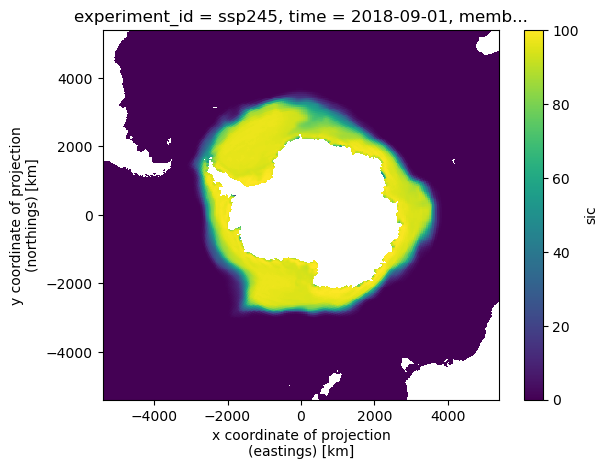

In [29]:
with ProgressBar():
    ensemble_mean(CMIP6_ES).sel(member_id='UKESM1-0-LL',time='2018-09').sic.plot()

[########################################] | 100% Completed | 5.34 sms


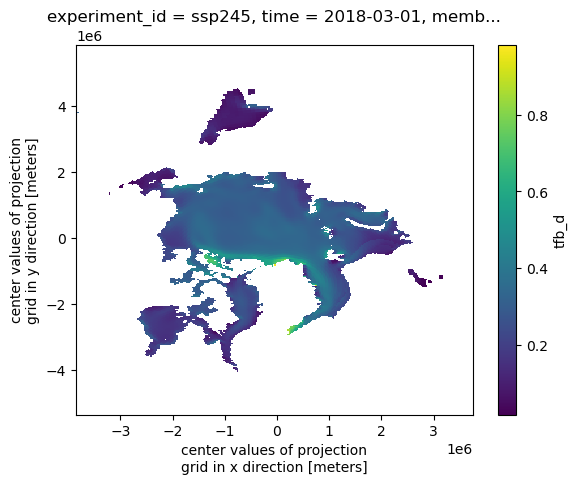

In [30]:
with ProgressBar():
    ensemble_mean(CMIP6_PN).sel(member_id='CESM2',time='2018-03').tfb_d.plot()